# Stochastic Gradient Descent

# Objectives

* See how Stochastic Gradient Descent can be used on a simple model (1-dim. linear regression)
* See how SGD can be used on a complex model (MLPClassifier)
* Understand impact of batch size and learning rate (aka step size)


# Outline
* [Review: Loss and Gradient for 1-dim. Linear Regression](#part1)
* [Part 1: Stochastic Estimates of the Loss](#part1)
* [Part 2: Stochastic Estimates of the Gradient](#part2)
* [Part 3: Stochastic Gradient Descent Algorithm in a few lines of Python](#part3)
* [Part 4: Using sklearn code to train MLPClassifier with SGD](#part4)

# Takeaways

* Stochastic estimates of loss functions are possible when the function is *additive* over training examples

* Stochastic gradient descent is a simple algorithm that can be implemented in a few lines of Python
* * Practical issues include selecting step size and batch size $B$

* Selecting batch size trades off two things:
* * Runtime cost of computing each gradient estimate (scales with $O(B)$, so smaller is better)
* * Quality of the estimate (larger $B$ leads to less variance)

In [1]:
import numpy as np

In [2]:
import sklearn.neural_network

In [ ]:
# import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', font_scale=1.25, style='whitegrid')

# Create simple dataset:   y = 1.234 * x + noise

We will *intentionally* create a toy dataset where we know that a good solution has slope near 1.234.

We'll generate N = 1000 examples.

Naturally, the best slope for the finite dataset we create won't be exactly 1.234 (because of the noise added plus the fact that our dataset size is limited).

In [4]:
def create_dataset(N=1000, slope=1.234, noise_stddev=0.1, random_state=0):
    random_state = np.random.RandomState(int(random_state))

    # input features
    x_N = np.linspace(-2, 2, N)
    
    # output features
    y_N = slope * x_N + random_state.randn(N) * noise_stddev
    
    return x_N, y_N

In [5]:
xtrain_N, ytrain_N = create_dataset(N=1000, noise_stddev=0.3)

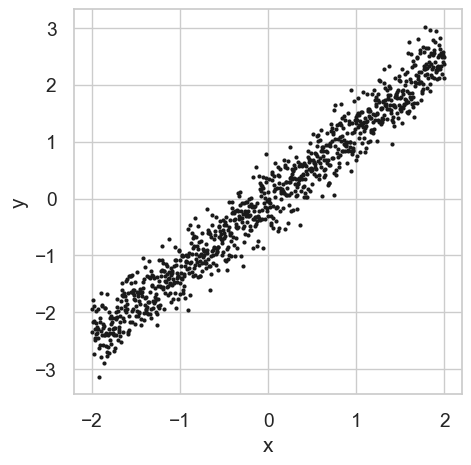

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
plt.plot(xtrain_N, ytrain_N, 'k.');
plt.xlabel('x');
plt.ylabel('y');

# Review: Gradient Descent for 1-dim. Linear Regression

## Define prediction model

Consider the *simplest* linear regression model. A single weight parameter $w \in \mathbb{R}$ representing the slope of the prediction line. No bias/intercept.

To make predictions, we just compute the weight multiplied by the input feature
$$
\hat{y}(x) = w \cdot x
$$

## Define loss function

We want to minimize the total *squared error* across all N observed data examples (input features $x_n$, output responses $y_n$)

Given a full dataset of $N$ examples, we can compute the loss as:

\begin{align}
    \min_{w \in \mathbb{R}} ~~ &J(w) \\
    \text{calc\_loss}(w) &= J(w) = \frac{1}{N} \sum_{n=1}^N \frac{1}{2} (y_n - w x_n)^2
\end{align}

Given a random minibatch of $B$ examples, we can *estimate* the loss as:

\begin{align}
    \text{estimate\_loss}(w) &= \frac{1}{B} \sum_{n=1}^B \frac{1}{2} (y_n - w x_n)^2
\end{align}

### Implementation 1A: Code the estimate_loss function

We've implemented the estimate of the loss via a function below

In [7]:
def calc_loss(w, xbatch_B, ybatch_B):
    ''' Compute loss for slope-only least-squares linear regression
    
    Will compute the estimate of the loss given a minibatch of x,y values
    
    Args
    ----
    w : float
        Value of slope parameter

    Returns
    -------
    loss : float
        Mean of squared error loss at provided w value
    '''
    B = xbatch_B.shape[0]
    yhat_B = xbatch_B * w
    half_mean_squared_error = 0.5 * np.mean(np.square(ybatch_B - yhat_B))
    return half_mean_squared_error

### Define the gradient function

Given a full dataset of $N$ examples, we can compute the gradient as:

\begin{align}
\text{calc\_grad}(w) = J'(w) &= \frac{1}{N} \frac{\partial}{\partial w} [ \sum_{n=1}^N \frac{1}{2} (y_n - w x_n)^2] 
\\
&= \frac{1}{N}  \sum_{n=1}^N (y_n - w x_n) (-x_n)
\\
&= \frac{1}{N} \sum_{n=1}^N (w x_n - y_n) (x_n)
\\
&= w \left( \frac{1}{N} \sum_{n=1}^N x_n^2 \right) - \frac{1}{N} \sum_{n=1}^N y_n x_n
\end{align}

Given a random minibatch of $B$ examples (assuming its members are indexed from 1, 2, to B), we can *estimate* the gradient using:

\begin{align}
\text{estimate\_grad}(w) &= \frac{1}{B} \frac{\partial}{\partial w} [ \sum_{n=1}^B \frac{1}{2} (y_n - w x_n)^2] 
\\
&= w \left( \frac{1}{B} \sum_{n=1}^B x_n^2 \right) - \frac{1}{B} \sum_{n=1}^B y_n x_n
\end{align}

Below, we've implemented the gradient calculation in code for you

In [8]:
def calc_grad(w, xbatch_B, ybatch_B):
    ''' Compute gradient for slope-only least-squares linear regression
    
    Will compute a deterministic estimate of the gradient given a minibatch of x,y values

    Args
    ----
    w : float
        Value of slope parameter

    Returns
    -------
    g : float
        Value of derivative of loss function at provided w value
    '''
    g = w * np.mean(np.square(xbatch_B)) - np.mean(xbatch_B * ybatch_B)
    return g

# Part 1: Stochastic estimates of the loss

### Plot whole-dataset loss evaluated at each w from -3 to 8

We should see a "bowl" shape with one *global* minima, because our optimization problem is "convex"

In [9]:
G = 101
w_grid = np.linspace(-3, 8, G) # create array of 300 values between -3 and 8
print(w_grid)

[-3.   -2.89 -2.78 -2.67 -2.56 -2.45 -2.34 -2.23 -2.12 -2.01 -1.9  -1.79
 -1.68 -1.57 -1.46 -1.35 -1.24 -1.13 -1.02 -0.91 -0.8  -0.69 -0.58 -0.47
 -0.36 -0.25 -0.14 -0.03  0.08  0.19  0.3   0.41  0.52  0.63  0.74  0.85
  0.96  1.07  1.18  1.29  1.4   1.51  1.62  1.73  1.84  1.95  2.06  2.17
  2.28  2.39  2.5   2.61  2.72  2.83  2.94  3.05  3.16  3.27  3.38  3.49
  3.6   3.71  3.82  3.93  4.04  4.15  4.26  4.37  4.48  4.59  4.7   4.81
  4.92  5.03  5.14  5.25  5.36  5.47  5.58  5.69  5.8   5.91  6.02  6.13
  6.24  6.35  6.46  6.57  6.68  6.79  6.9   7.01  7.12  7.23  7.34  7.45
  7.56  7.67  7.78  7.89  8.  ]


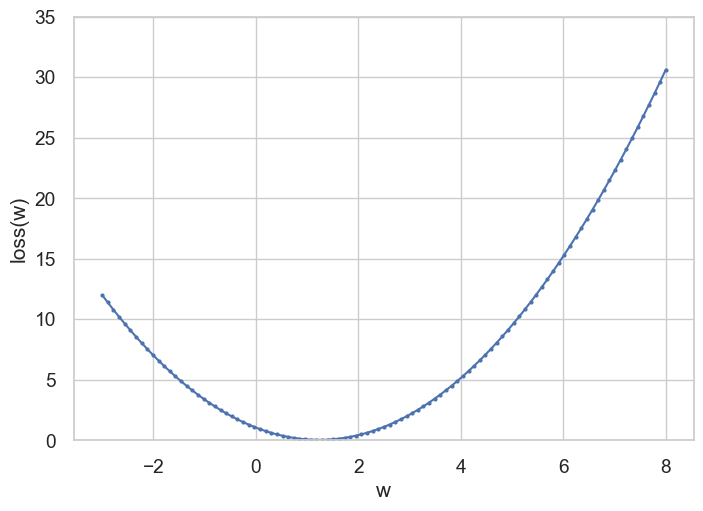

In [10]:
loss_grid = np.zeros(G)
for gg in range(G):
    loss_grid[gg] = calc_loss(w_grid[gg], xtrain_N, ytrain_N)

plt.plot(w_grid, loss_grid, 'b.-');
plt.xlabel('w');
plt.ylabel('loss(w)');
plt.ylim([0, 35]);

### Sampling a minibatch of size B

We have provided some starter code that samples a minibatch of B examples from a training set of N examples

Uses a provided `random_state` pseudo-random number generator, which defaults to numpy's if not specified.

In [11]:
def draw_minibatch(xtrain_N, ytrain_N, batch_size=100, random_state=np.random):
    ''' Sample a minibatch of desired size from provided training set
    
    Returns
    -------
    xbatch_B : 1D array, size (B,)
        x values of minibatch
    ybatch_B : 1D array, size (B,)
        y values of minibatch
    '''
    N = ytrain_N.size
    selected_row_ids = random_state.choice(np.arange(N), size=batch_size, replace=False)
    xbatch_B = xtrain_N[selected_row_ids].copy()
    ybatch_B = ytrain_N[selected_row_ids].copy()
    return xbatch_B, ybatch_B

### Show several minibatches of size 1

In [12]:
draw_minibatch(xtrain_N, ytrain_N, 1)

(array([1.62762763]), array([1.85201859]))

In [13]:
draw_minibatch(xtrain_N, ytrain_N, 1)

(array([-1.84784785]), array([-2.39644229]))

In [14]:
draw_minibatch(xtrain_N, ytrain_N, 1)

(array([1.3953954]), array([1.49701081]))

### Show example minibatch of size 500


In [15]:
xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, 500)

print("Showing first 5 entries of x array of shape %s" % str(xbatch_B.shape))
print(xbatch_B[:5])
print("Showing first 5 entries of y array of shape %s" % str(ybatch_B.shape))
print(ybatch_B[:5])

Showing first 5 entries of x array of shape (500,)
[ 0.56656657 -0.48248248 -0.73473473  1.71971972  0.97097097]
Showing first 5 entries of y array of shape (500,)
[ 1.10942232 -0.33132971 -0.9193141   2.56353072  1.72467402]


Show the loss at this random minibatch when $w = 1.0$

In [16]:
calc_loss(1.0, xbatch_B, ybatch_B)

np.float64(0.07503063390661975)

Show the loss at this random minibatch when w = -2.0

In [17]:
calc_loss(-1.0, xbatch_B, ybatch_B)

np.float64(3.302041324201142)

### Exercise 1c: Can you draw a random minibatch of size 25 and display *all* of it?

In [42]:
xbatch_25, ybatch_25 = draw_minibatch(xtrain_N, ytrain_N, 25)

print("Showing x array")
print(xbatch_25)
print("Showing y array")
print(ybatch_25)


Showing x array
[-1.48348348 -1.03503504 -1.38738739  1.26326326  0.38238238 -1.97197197
 -1.07107107  0.55055055  1.81181181  0.21021021  0.64264264  1.93993994
 -1.17117117  1.79179179  1.84784785  0.08208208 -2.         -0.7027027
  1.58358358  1.8038038   0.66266266  0.67867868  1.45145145  1.92792793
  1.93593594]
Showing y array
[-1.70838007 -1.39641478 -1.9599676   2.07963057  0.58563052 -2.47882058
 -1.48456014  0.75512837  2.65617923  0.54213984  0.51319875  2.11252182
 -1.6666345   2.64158589  2.56167201  0.03450759 -1.9387843  -1.21434171
  2.55352897  1.94164732  0.62292435  0.95055245  1.7974097   2.33569302
  2.70832049]


### Exercise 1d: What is the loss at your minibatch at $w=1.0$ and $w = 1.5$?

In [43]:
w1_loss = calc_loss(1, xbatch_25, ybatch_25)
w1_5_loss = calc_loss(1.5, xbatch_25, ybatch_25)

print("w = 1:", w1_loss)
print("w = 1.5:", w1_5_loss)

w = 1: 0.12437945287952439
w = 1.5: 0.0789576614733123


## Plot: Compute the *stochastic estimate* of loss as a function of $w$, using batch size 50

We'll make 3 lines, for 3 separate *trials* of this procedure, so we can see how much each trial's curve might vary

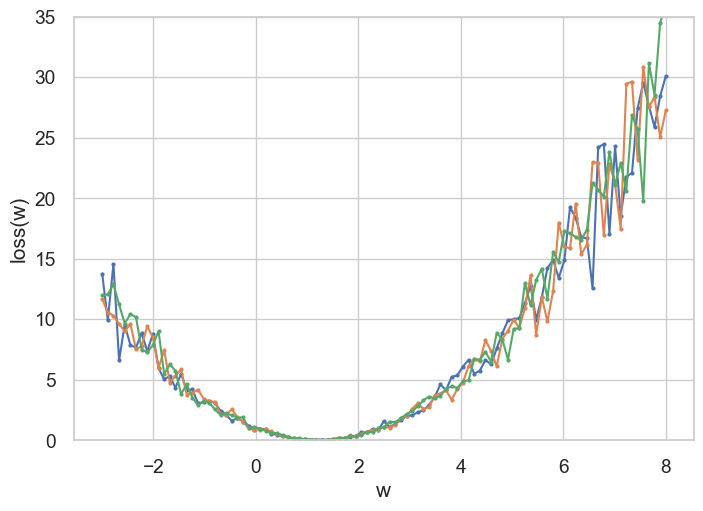

In [44]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_loss_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, batch_size=50, random_state=random_state)
        stoch_loss_grid[gg] = calc_loss(w_grid[gg], xbatch_B, ybatch_B)

    plt.plot(w_grid, stoch_loss_grid, '.-', label='Trial %d' % trial);
plt.xlabel('w');
plt.ylabel('loss(w)');
plt.ylim([0, 35]);

## Exercise 1e: Compute stochastic estimate of loss as function of w, for batch_size = 5

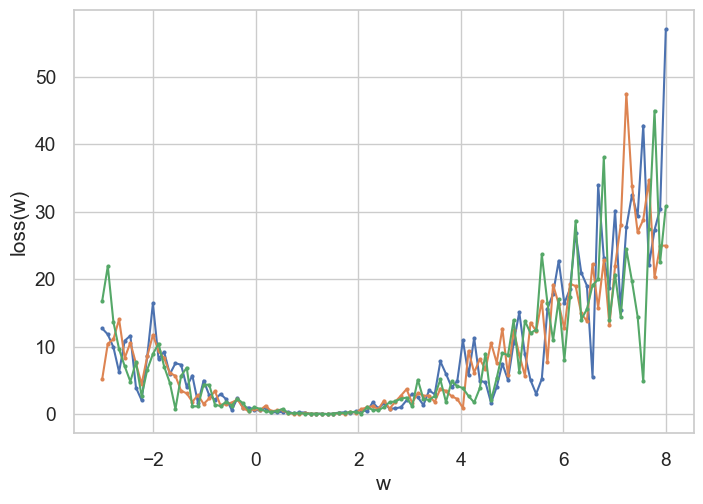

In [45]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_loss_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, 5, random_state=random_state)
        stoch_loss_grid[gg] = calc_loss(w_grid[gg], xbatch_B, ybatch_B) 

    plt.plot(w_grid, stoch_loss_grid, '.-', label='Trial %d' % trial);
    
    
plt.xlabel('w');
plt.ylabel('loss(w)');

## Exercise 1f: Compute stochastic estimate of loss as function of w, for batch_size = 1

Repeat the above for batch_size = 1

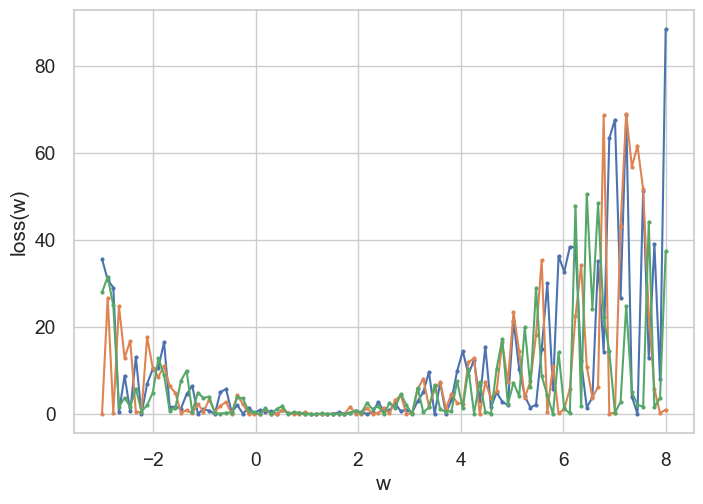

In [46]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_loss_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, 1, random_state=random_state)
        stoch_loss_grid[gg] = calc_loss(w_grid[gg], xbatch_B, ybatch_B) 

    plt.plot(w_grid, stoch_loss_grid, '.-', label='Trial %d' % trial);
    
    
plt.xlabel('w');
plt.ylabel('loss(w)');

## Discussion 1f: What can you say about the *variance* of the stochastic estimates

How does variance change as a function of batch size ?

variance of estimates increease as batch size falls

## Part 2: Stochastic estimates of the gradient

## Sanity check: plot whole dataset gradient evaluated at each w from -3 to 8

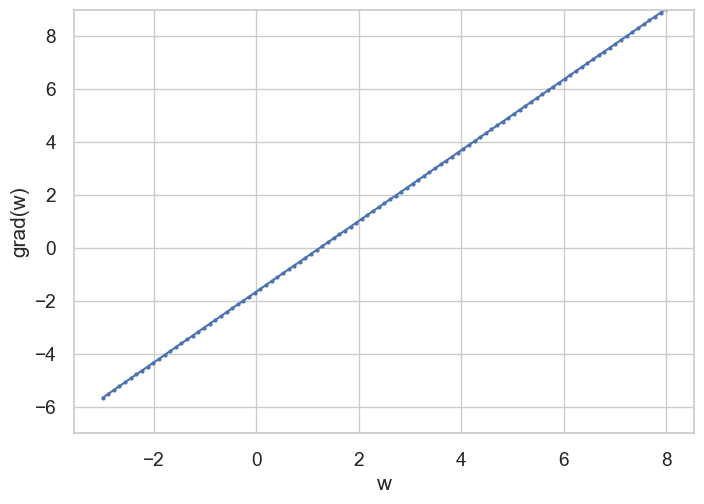

In [22]:
grad_grid = np.zeros(G)
for gg in range(G):
    grad_grid[gg] = calc_grad(w_grid[gg], xtrain_N, ytrain_N)

plt.plot(w_grid, grad_grid, 'b.-');
plt.xlabel('w');
plt.ylabel('grad(w)');
plt.ylim([-7, 9]);

## Plot: Compute the *stochastic estimate* of grad as a function of $w$, using batch size 50

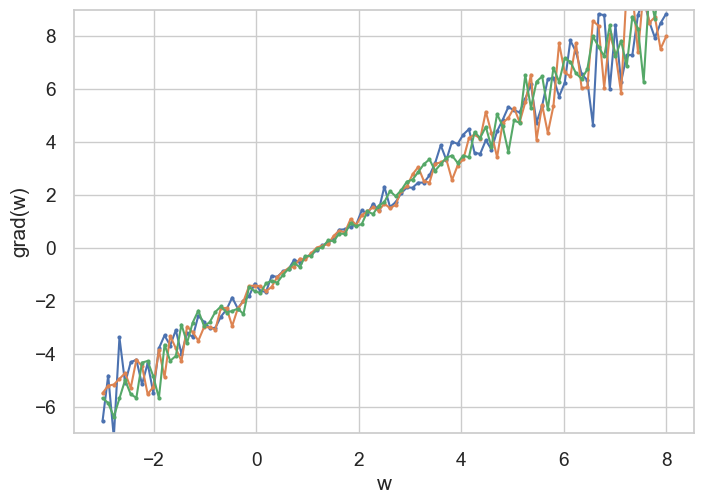

In [47]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_grad_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, batch_size=50, random_state=random_state)
        stoch_grad_grid[gg] = calc_grad(w_grid[gg], xbatch_B, ybatch_B)
        
    plt.plot(w_grid, stoch_grad_grid, '.-', label='Trial %d' % trial);
    

plt.xlabel('w');
plt.ylabel('grad(w)');
plt.ylim([-7, 9]);

## Exercise 2a: Repeat the above plot at batch_size = 5


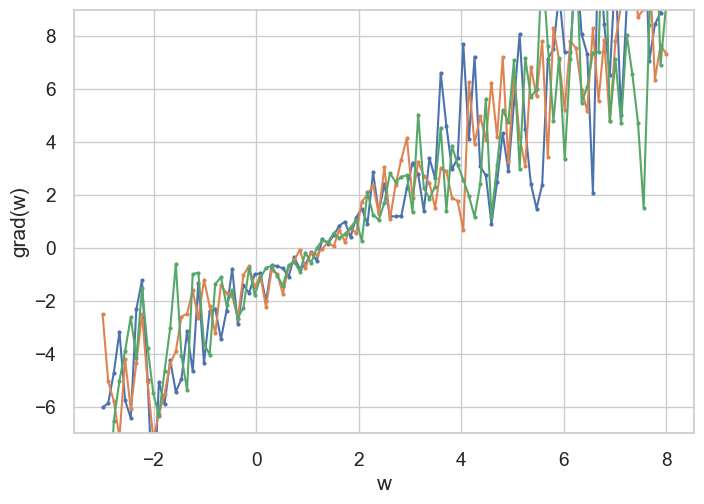

In [49]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_grad_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, batch_size=5, random_state=random_state)
        stoch_grad_grid[gg] = calc_grad(w_grid[gg], xbatch_B, ybatch_B)
        
    plt.plot(w_grid, stoch_grad_grid, '.-', label='Trial %d' % trial);
    

plt.xlabel('w');
plt.ylabel('grad(w)');
plt.ylim([-7, 9]);

## Exercise 2c: Repeat the above plot at batch_size = 1


TODO copy code from above.

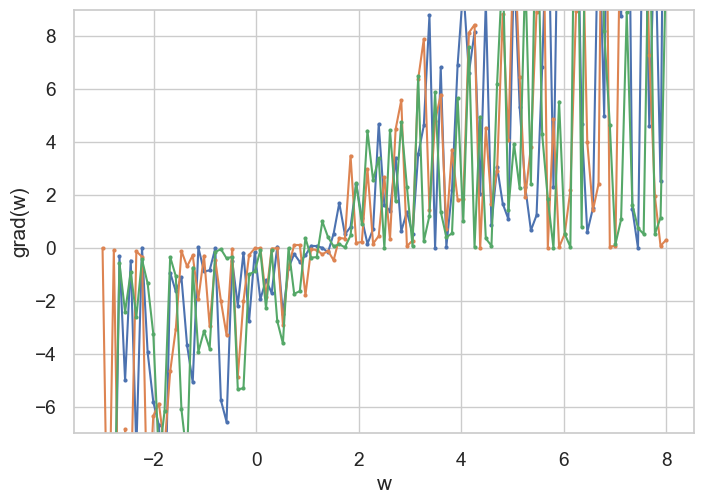

In [50]:
for trial in range(3):
    random_state = np.random.RandomState(trial) # set seed based on the trial id

    stoch_grad_grid = np.zeros(G)
    for gg in range(G):
        xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, batch_size=1, random_state=random_state)
        stoch_grad_grid[gg] = calc_grad(w_grid[gg], xbatch_B, ybatch_B)
        
    plt.plot(w_grid, stoch_grad_grid, '.-', label='Trial %d' % trial);
    

plt.xlabel('w');
plt.ylabel('grad(w)');
plt.ylim([-7, 9]);

## Part 3: Stochastic Gradient Descent (GD) as an algorithm in Python

### Define minimize_via_sgd algorithm

Can you understand what each step of this algorithm does?

In [26]:
def minimize_via_sgd(xtrain_N, ytrain_N, init_w=0.0, batch_size=10, step_size=0.001, max_iters=100, random_state=0):
    ''' Perform minimization of provided loss function via gradient descent
    
    Each "iteration" performs one or more gradient updates, until total training set has been "seen"
    
    Args
    ----
    xtrain_N : numpy array, shape (N,)
    ytrain_N : numpy array, shape (N,)
    init_w : float
    batch_size : int
    step_size : float
    max_iters : positive int
    
    Return
    ----
    wopt: float
        array of optimized weights that approximately gives the least error
    info_dict : dict
        Contains information about the optimization procedure useful for debugging
        Entries include:
        * trace_loss_list : list of loss values
        * trace_grad_list : list of gradient values
    '''
    N = int(ytrain_N.size)
    B = int(batch_size)
    
    if isinstance(random_state, int):
        random_state = np.random.RandomState(random_state)

    w = 1.0 * init_w 
    
    # Create some lists to track progress over time (for debugging)
    trace_loss_list = []
    trace_w_list = []
    trace_grad_list = []

    step_id = 0
    for iter_id in range(max_iters):
        
        n_examples_seen_this_iter = 0
        while n_examples_seen_this_iter < N:
            xbatch_B, ybatch_B = draw_minibatch(xtrain_N, ytrain_N, batch_size, random_state=random_state)
            n_examples_seen_this_iter += batch_size
            
            loss = calc_loss(w, xbatch_B, ybatch_B)    
            grad = calc_grad(w, xbatch_B, ybatch_B)    
            w = w - step_size * grad
            step_id += 1

        print("  iter %5d/%d done | step %5d | w  % 13.5f | loss % 13.4f | grad % 13.4f" % (
            iter_id, max_iters, step_id, w, loss, grad))
    
        trace_loss_list.append(loss)
        trace_w_list.append(w)
        trace_grad_list.append(grad)
    
    wopt = w
    info_dict = dict(
        trace_loss_list=trace_loss_list,
        trace_w_list=trace_w_list, 
        trace_grad_list=trace_grad_list)
    
    return wopt, info_dict

### Try it! Run SGD with step_size = 0.01 and batch_size = 200

Running the cell below will have the following effects:

1) one line will be printed for every iteration, indicating the current w value and its associated loss

2) the "optimal" value of w will be stored in the variable named `wopt` returned by this function

3) a dictionary of information useful for debugging will be stored in the `info_dict` returned by this function

In [27]:
wopt, info_dict = minimize_via_sgd(xtrain_N, ytrain_N, step_size=0.01, batch_size=200);

  iter     0/100 done | step     5 | w        0.08015 | loss        1.0488 | grad       -1.7202
  iter     1/100 done | step    10 | w        0.15328 | loss        0.8576 | grad       -1.4773
  iter     2/100 done | step    15 | w        0.22259 | loss        0.7444 | grad       -1.3535
  iter     3/100 done | step    20 | w        0.28735 | loss        0.6190 | grad       -1.2232
  iter     4/100 done | step    25 | w        0.35058 | loss        0.5804 | grad       -1.2300
  iter     5/100 done | step    30 | w        0.40936 | loss        0.5670 | grad       -1.2455
  iter     6/100 done | step    35 | w        0.46134 | loss        0.4426 | grad       -1.0366
  iter     7/100 done | step    40 | w        0.51053 | loss        0.3971 | grad       -0.9791
  iter     8/100 done | step    45 | w        0.55889 | loss        0.3367 | grad       -0.8819
  iter     9/100 done | step    50 | w        0.60231 | loss        0.3295 | grad       -0.8519
  iter    10/100 done | step    55 | w  

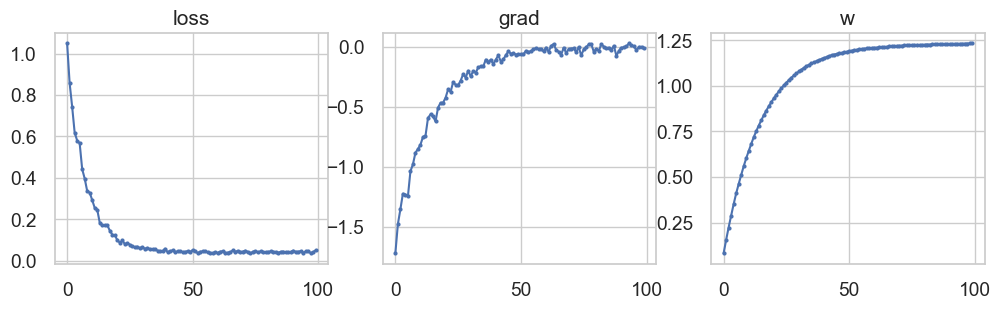

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=False, figsize=(12,3))

axes[0].plot(info_dict['trace_loss_list'], '.-');
axes[0].set_title('loss');
axes[1].plot(info_dict['trace_grad_list'], '.-');
axes[1].set_title('grad');
axes[2].plot(info_dict['trace_w_list'], '.-');
axes[2].set_title('w');

## Try with smaller batch_size = 10

In [29]:
wopt, info_dict = minimize_via_sgd(xtrain_N, ytrain_N, step_size=0.01, batch_size=10);

  iter     0/100 done | step   100 | w        0.91625 | loss        0.1191 | grad       -0.3511
  iter     1/100 done | step   200 | w        1.14951 | loss        0.0377 | grad        0.0505
  iter     2/100 done | step   300 | w        1.20424 | loss        0.0991 | grad        0.1091
  iter     3/100 done | step   400 | w        1.23031 | loss        0.0381 | grad        0.0042
  iter     4/100 done | step   500 | w        1.23886 | loss        0.0511 | grad       -0.2389
  iter     5/100 done | step   600 | w        1.24595 | loss        0.0859 | grad       -0.1187
  iter     6/100 done | step   700 | w        1.25205 | loss        0.0334 | grad        0.1019
  iter     7/100 done | step   800 | w        1.23007 | loss        0.0334 | grad       -0.0147
  iter     8/100 done | step   900 | w        1.22628 | loss        0.0573 | grad        0.0265
  iter     9/100 done | step  1000 | w        1.23810 | loss        0.0412 | grad        0.0452
  iter    10/100 done | step  1100 | w  

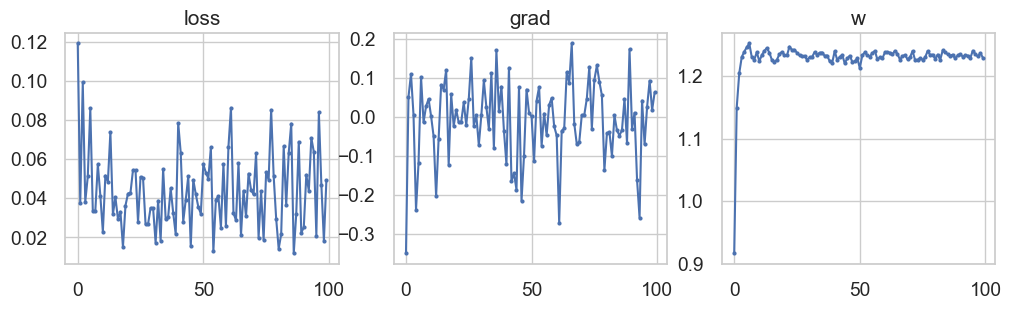

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=False, figsize=(12,3))

axes[0].plot(info_dict['trace_loss_list'], '.-');
axes[0].set_title('loss');
axes[1].plot(info_dict['trace_grad_list'], '.-');
axes[1].set_title('grad');
axes[2].plot(info_dict['trace_w_list'], '.-');
axes[2].set_title('w');

### Try with even smaller batch_size of 1

In [51]:
wopt, info_dict = minimize_via_sgd(xtrain_N, ytrain_N, step_size=0.01, batch_size=1);

  iter     0/100 done | step  1000 | w        1.23833 | loss        0.0090 | grad        0.2675
  iter     1/100 done | step  2000 | w        1.24311 | loss        0.0342 | grad        0.1084
  iter     2/100 done | step  3000 | w        1.22439 | loss        0.0282 | grad       -0.2963
  iter     3/100 done | step  4000 | w        1.18008 | loss        0.0543 | grad       -0.0033
  iter     4/100 done | step  5000 | w        1.20593 | loss        0.0096 | grad        0.1081
  iter     5/100 done | step  6000 | w        1.19016 | loss        0.0238 | grad        0.0520
  iter     6/100 done | step  7000 | w        1.23273 | loss        0.0355 | grad        0.0251
  iter     7/100 done | step  8000 | w        1.24029 | loss        0.0135 | grad        0.1538
  iter     8/100 done | step  9000 | w        1.22694 | loss        0.0393 | grad        0.3789
  iter     9/100 done | step 10000 | w        1.21816 | loss        0.1192 | grad        0.2180
  iter    10/100 done | step 11000 | w  

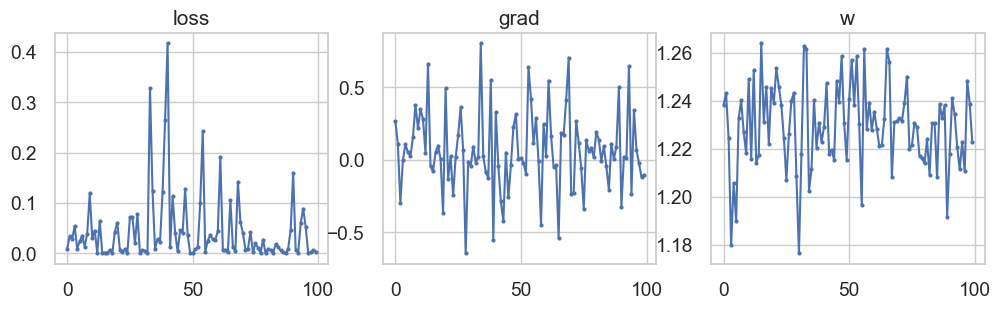

In [52]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=False, figsize=(12,3))

axes[0].plot(info_dict['trace_loss_list'], '.-');
axes[0].set_title('loss');
axes[1].plot(info_dict['trace_grad_list'], '.-');
axes[1].set_title('grad');
axes[2].plot(info_dict['trace_w_list'], '.-');
axes[2].set_title('w');

# Part 5: SGD for MLPClassifier



Let's revisit the XOR dataset from our previous lab, and try SGD for it.

In [53]:
def make_xor_dataset(n_per_blob=50, stddev=0.4, random_state=0):
    random_state = np.random.RandomState(random_state)
    cov_22 = np.square(stddev) * np.eye(2)
    x_00 = random_state.multivariate_normal([-1, -1], cov_22, size=n_per_blob)
    x_01 = random_state.multivariate_normal([-1, +1], cov_22, size=n_per_blob)
    x_10 = random_state.multivariate_normal([+1, -1], cov_22, size=n_per_blob)
    x_11 = random_state.multivariate_normal([+1, +1], cov_22, size=n_per_blob)

    N = n_per_blob * 4
    x_N2 = np.vstack([x_00, x_11, x_01, x_10])
    assert x_N2.shape == (N, 2)

    y_N = np.hstack([np.ones(N//2), np.zeros(N//2)]).astype(np.int32)
    assert y_N.shape == (N,)

    # Shuffle the order
    perm_ids = random_state.permutation(N)
    x_N2 = x_N2[perm_ids].copy()
    y_N = y_N[perm_ids].copy()

    return x_N2, y_N

In [33]:
x_tr_N2, y_tr_N = make_xor_dataset(n_per_blob=50)

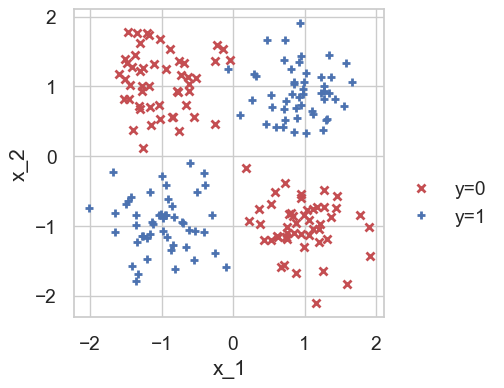

In [34]:
plt.figure(figsize=(4,4))
plt.plot(x_tr_N2[y_tr_N==0,0], x_tr_N2[y_tr_N==0,1], 'rx', label='y=0', mew=2);
plt.plot(x_tr_N2[y_tr_N==1,0], x_tr_N2[y_tr_N==1,1], 'b+', label='y=1', mew=2);

plt.xlabel('x_1');
plt.ylabel('x_2');
plt.legend(bbox_to_anchor=(1.0, 0.5));

# Setup: Create Utility function for visualizing classifier predictions

You do NOT need to understand the details of this function. We'll just use it as is.

In [35]:
def plot_pretty_probabilities_for_clf(
        clf,
        ax=None,
        x1_grid=(-2.1, 2.1, 50), x2_grid=(-2.1, 2.1, 50),
        x1_ticks=[-1, 0, 1], x2_ticks=[-1, 0, 1],
        do_show_colorbar=False,
        c_ticks=np.asarray([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
        c_num_levels=100,
        ):
    ''' Display predicted probabilities from classifier as color contour plot

    Args
    ----
    clf : sklearn object that implements classifier API
    ax : matplotlib axis handle, or None
        If provided, will use axis handle as primary axis to plot on.
        If None, will use the current handle, or make new one as necessary.
    x1_grid : tuple-like or array-like
        If tuple of length 3, interpreted as args to np.linspace
        Otherwise, cast to array and assumed to be a 1d grid of x1 values
    x2_grid : tuple-like or array-like
        If tuple of length 3, interpreted as args to np.linspace
        Otherwise, cast to array and assumed to be a 1d grid of x2 values

    '''
    # Activate the current axis, if necessary
    if ax is None:
        cur_ax = plt.gca()
    else:
        cur_ax = ax
        plt.sca(cur_ax)

    # Create dense grid of x1 and x2 values
    # useful for visualizing probabilities
    if isinstance(x1_grid, tuple) and len(x1_grid) == 3:
        x1_grid = np.linspace(x1_grid[0], x1_grid[1], x1_grid[2])
    if isinstance(x2_grid, tuple) and len(x2_grid) == 3:
        x2_grid = np.linspace(x2_grid[0], x2_grid[1], x2_grid[2])
    x1_grid = np.asarray(x1_grid).flatten()
    x2_grid = np.asarray(x2_grid).flatten()

    c_levels = np.linspace(0.0, 1.0, c_num_levels)

    # Get regular grid of G x H points, where each point is an (x1, x2) location
    G = x1_grid.size
    H = x2_grid.size    
    x1_GH, x2_GH = np.meshgrid(x1_grid, x2_grid)
    
    # Combine the x1 and x2 values into one array
    # Flattened into M = G x H rows
    # Each row of x_M2 is a 2D vector [x_m1, x_m2]
    x_M2 = np.hstack([x1_GH.flatten()[:,np.newaxis], x2_GH.flatten()[:,np.newaxis]])
    
    # Predict proba for each point in the flattened grid
    yproba1_M = clf.predict_proba(x_M2)[:,1]
    # Reshape the M probas into the GxH 2D field
    yproba1_GH = np.reshape(yproba1_M, x1_GH.shape)
    # Contour plot
    cmap = plt.cm.RdYlBu
    my_contourf_h = plt.contourf(
            x1_GH, x2_GH, yproba1_GH,
            levels=c_levels, vmin=0, vmax=1.0,
            cmap=cmap, alpha=0.5)

    # Edit the ticks observed
    if x1_ticks is not None:
        plt.xticks(x1_ticks, x1_ticks);
    if x2_ticks is not None:
        plt.yticks(x2_ticks, x2_ticks);
    if do_show_colorbar:
        left, bottom, width, height = plt.gca().get_position().bounds
        cax = plt.gcf().add_axes([left + 1.1*width, bottom, 0.03, height])
        plt.colorbar(my_contourf_h, orientation='vertical', cax=cax, ticks=c_ticks);
        plt.sca(cur_ax);

## Try an MLP with 2 hidden units, batch size of 25

This time, we'll use SGD as built in solver

In [36]:
mlp_2hidden_run5 = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=[2],
    activation='relu',
    solver='sgd',
    learning_rate_init=0.1,
    random_state=5,
    batch_size=25,
    )

In [37]:
# Fit the model to training data

mlp_2hidden_run5.fit(x_tr_N2, y_tr_N)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",[2]
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",25
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.1
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",5


### Visualize the results using our utility function


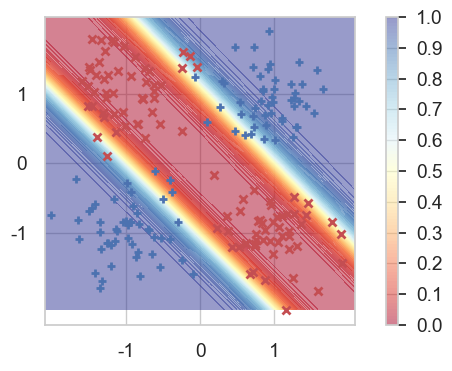

In [38]:
plt.figure(figsize=(4,4))
plot_pretty_probabilities_for_clf(mlp_2hidden_run5, do_show_colorbar=True, ax=plt.gca());

plt.plot(x_tr_N2[y_tr_N==0,0], x_tr_N2[y_tr_N==0,1], 'rx', label='y=0', mew=2);
plt.plot(x_tr_N2[y_tr_N==1,0], x_tr_N2[y_tr_N==1,1], 'b+', label='y=1', mew=2);

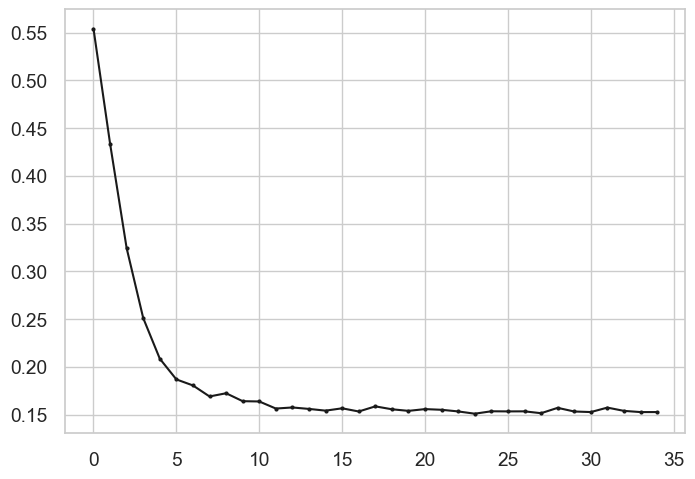

In [39]:
### Visualize the trace of the loss

plt.plot(mlp_2hidden_run5.loss_curve_, 'k.-')

# Try several trials with batch_size of 25

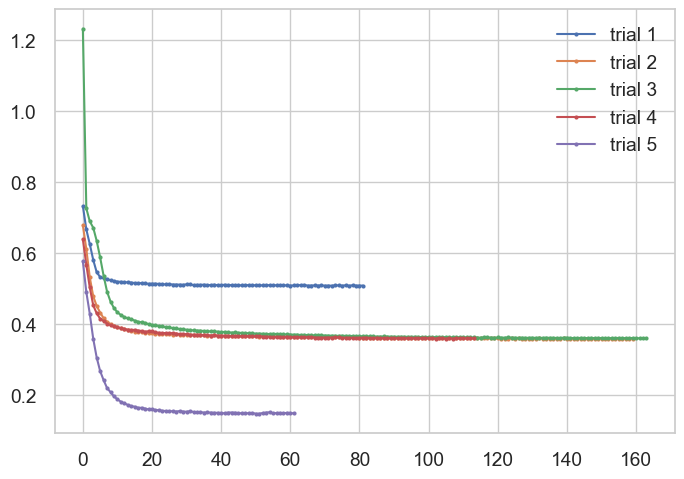

In [55]:
for trial in [1, 2, 3, 4, 5]:
    mlp_2hidden_batchsize25 = sklearn.neural_network.MLPClassifier(
        hidden_layer_sizes=[2],
        activation='relu',
        solver='sgd',
        learning_rate_init=0.05,
        random_state=trial,
        batch_size=25,
        )
    
    # Fit the model to training data
    mlp_2hidden_batchsize25.fit(x_tr_N2, y_tr_N)
    
    # Visualize the trace of the loss
    plt.plot(mlp_2hidden_batchsize25.loss_curve_, '.-', label='trial %d' % trial)
    
plt.legend();

### Now try several trials with a batch_size of 1

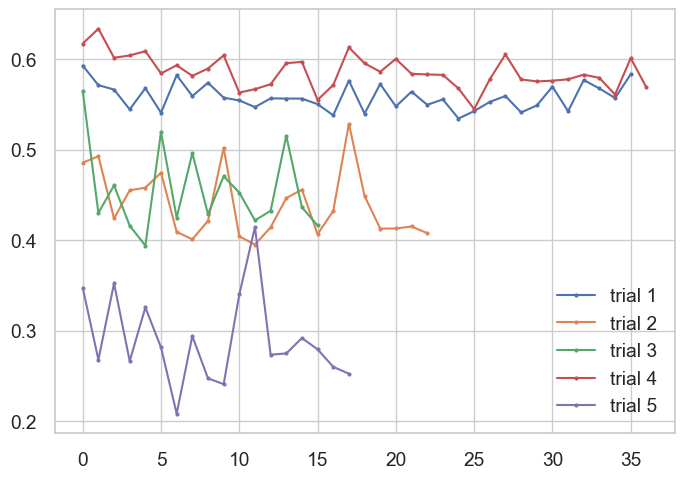

In [41]:
for trial in [1, 2, 3, 4, 5]:
    mlp_2hidden_batchsize1 = sklearn.neural_network.MLPClassifier(
        hidden_layer_sizes=[2],
        activation='relu',
        solver='sgd',
        learning_rate_init=0.05,
        random_state=trial,
        batch_size=1,
        )
    
    # Fit the model to training data
    mlp_2hidden_batchsize1.fit(x_tr_N2, y_tr_N)
    
    # Visualize the trace of the loss
    plt.plot(mlp_2hidden_batchsize1.loss_curve_, '.-', label='trial %d' % trial)
    
plt.legend();

### Discussion 4a: What is happening here?

Multiple local minima, and lower batch sizes interfere with convergence